# Curvas ROC e Precisão-Recall

**Tema:** Avaliação e Validação de Modelos › Métricas de Classificação

Construímos a curva ROC e a AUC do zero (por trapézios e pela contagem de
pares de Mann-Whitney), a curva PR e a average precision, conferimos
tudo contra o `scikit-learn`, e depois exploramos: o efeito da
prevalência, Gini e KS do mercado de crédito, curvas de ganho e lift, e
dois modelos cujas curvas ROC se cruzam.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve)
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(612)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O exemplo de pares do `teoria.pdf`

In [2]:
pos = np.array([0.9, 0.6, 0.4]); neg = np.array([0.7, 0.3, 0.2, 0.1])
pares = (pos[:, None] > neg[None, :]).sum() + 0.5 * (pos[:, None] == neg[None, :]).sum()
y_ex = np.r_[np.ones(3), np.zeros(4)]; s_ex = np.r_[pos, neg]
print(f"pares vencidos: {pares:.0f} de {len(pos) * len(neg)} -> AUC = {pares / 12:.3f} | "
      f"roc_auc_score = {roc_auc_score(y_ex, s_ex):.3f}")

pares vencidos: 10 de 12 -> AUC = 0.833 | roc_auc_score = 0.833


## 2. ROC e AUC do zero

In [3]:
def gera(n, prev, semente):
    g = np.random.default_rng(semente)
    y = (g.random(n) < prev).astype(int)
    X = g.normal(0, 1, (n, 4)) + y[:, None] * np.array([1.0, 0.7, 0.5, 0.0])
    return X, y

X, y = gera(12000, 0.10, 1)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.5, random_state=0, stratify=y)
s = LogisticRegression().fit(X_tr, y_tr).decision_function(X_te)

def roc_do_zero(y, s):
    ordem = np.argsort(-s)
    y_ord = y[ordem]
    tpr = np.r_[0, np.cumsum(y_ord) / y_ord.sum()]
    fpr = np.r_[0, np.cumsum(1 - y_ord) / (1 - y_ord).sum()]
    return fpr, tpr

fpr, tpr = roc_do_zero(y_te, s)
auc_trap = np.trapezoid(tpr, fpr)
U = mannwhitneyu(s[y_te == 1], s[y_te == 0]).statistic
auc_mw = U / ((y_te == 1).sum() * (y_te == 0).sum())
print(f"AUC por trapézios: {auc_trap:.4f} | por Mann-Whitney: {auc_mw:.4f} | "
      f"sklearn: {roc_auc_score(y_te, s):.4f}")

AUC por trapézios: 0.8259 | por Mann-Whitney: 0.8259 | sklearn: 0.8259


## 3. PR e average precision do zero

In [4]:
def ap_do_zero(y, s):
    ordem = np.argsort(-s)
    y_ord = y[ordem]
    vp = np.cumsum(y_ord)
    precisao = vp / np.arange(1, len(y) + 1)
    recall = vp / y.sum()
    ganho_recall = np.diff(np.r_[0, recall])       # só é > 0 onde entra um positivo
    return np.sum(ganho_recall * precisao), precisao, recall

ap, prec_z, rec_z = ap_do_zero(y_te, s)
prec_sk, rec_sk, _ = precision_recall_curve(y_te, s)
print(f"AP do zero: {ap:.4f} | sklearn: {average_precision_score(y_te, s):.4f}")
print(f"área por trapézios na curva PR (NÃO é o mesmo que AP): {np.trapezoid(prec_sk[::-1], rec_sk[::-1]):.4f}")

AP do zero: 0.4114 | sklearn: 0.4114
área por trapézios na curva PR (NÃO é o mesmo que AP): 0.4108


Com milhares de pontos, as duas contas quase coincidem. Com poucos
positivos, porém, a interpolação linear entre pontos da curva PR pode ser
bem otimista (Davis & Goadrich, 2006): ao contrário da ROC, a precisão não
varia linearmente entre dois pontos da curva. A average precision, que usa
a precisão observada em cada ponto de ganho de recall, é a forma
recomendada de resumir a curva.

## 4. Prevalência: ROC estável, PR não

In [5]:
modelo = LogisticRegression().fit(*gera(20000, 0.10, 3))
linhas = []
for prev in [0.5, 0.2, 0.1, 0.02, 0.005]:
    Xp, yp = gera(80000, prev, 9)
    sp = modelo.decision_function(Xp)
    linhas.append({"prevalência": prev, "ROC-AUC": roc_auc_score(yp, sp),
                   "AP": average_precision_score(yp, sp), "AP de um modelo aleatório": prev})
print(pd.DataFrame(linhas).round(3).to_string(index=False))

 prevalência  ROC-AUC    AP  AP de um modelo aleatório
       0.500    0.826 0.822                      0.500
       0.200    0.829 0.584                      0.200
       0.100    0.826 0.407                      0.100
       0.020    0.835 0.144                      0.020
       0.005    0.836 0.038                      0.005


## 5. Gini e KS: a linguagem do crédito

AUC = 0.826 | Gini = 2*AUC - 1 = 0.652 | KS = max(TPR - FPR) = 0.517
limiar do KS (= estatística de Youden): -2.055 (na escala do escore)


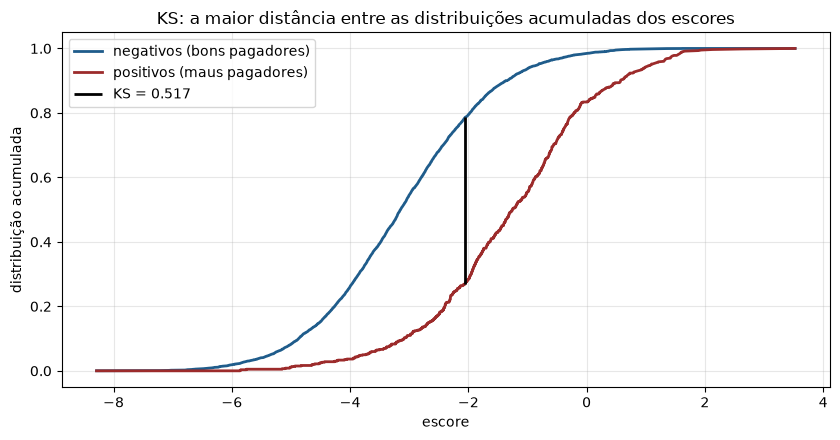

In [6]:
fpr_s, tpr_s, lim_s = roc_curve(y_te, s)
auc = roc_auc_score(y_te, s)
ks = np.max(tpr_s - fpr_s)
print(f"AUC = {auc:.3f} | Gini = 2*AUC - 1 = {2 * auc - 1:.3f} | KS = max(TPR - FPR) = {ks:.3f}")
print(f"limiar do KS (= estatística de Youden): {lim_s[np.argmax(tpr_s - fpr_s)]:.3f} (na escala do escore)")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
grade = np.sort(s)
acum_pos = np.searchsorted(np.sort(s[y_te == 1]), grade, side="right") / (y_te == 1).sum()
acum_neg = np.searchsorted(np.sort(s[y_te == 0]), grade, side="right") / (y_te == 0).sum()
ax.plot(grade, acum_neg, color=AZUL, lw=2, label="negativos (bons pagadores)")
ax.plot(grade, acum_pos, color=VERMELHO, lw=2, label="positivos (maus pagadores)")
i = np.argmax(acum_neg - acum_pos)
ax.vlines(grade[i], acum_pos[i], acum_neg[i], color="black", lw=2, label=f"KS = {acum_neg[i] - acum_pos[i]:.3f}")
ax.set_xlabel("escore"); ax.set_ylabel("distribuição acumulada"); ax.legend()
ax.set_title("KS: a maior distância entre as distribuições acumuladas dos escores")
plt.tight_layout(); plt.show()

## 6. Ganho acumulado e lift

In [7]:
ordem = np.argsort(-s)
ganho = np.cumsum(y_te[ordem]) / y_te.sum()
for frac in [0.05, 0.10, 0.20, 0.50]:
    k = int(frac * len(s))
    print(f"contatando os {frac:>4.0%} de maior escore: {ganho[k - 1]:.1%} dos positivos | "
          f"lift = {y_te[ordem[:k]].mean() / y_te.mean():.2f}")

contatando os   5% de maior escore: 25.1% dos positivos | lift = 5.02
contatando os  10% de maior escore: 44.5% dos positivos | lift = 4.45
contatando os  20% de maior escore: 62.1% dos positivos | lift = 3.11
contatando os  50% de maior escore: 89.0% dos positivos | lift = 1.78


## 7. Curvas que se cruzam: a AUC não conta a história toda

Dois modelos com AUCs parecidas. Um é melhor na região de FPR baixa (a
única aceitável se cada falso positivo bloqueia um cliente); o outro,
na região de recall alto.

modelo A: AUC = 0.711 | TPR com FPR <= 2%: 0.427
modelo B: AUC = 0.801 | TPR com FPR <= 2%: 0.185


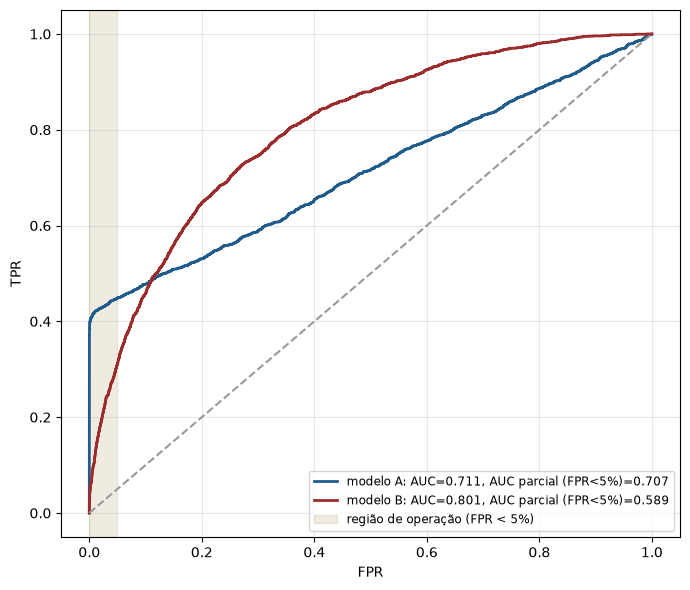

In [8]:
# Escores construídos para ilustrar o fenômeno (20 mil casos, 10% positivos):
# - modelo A reconhece com quase certeza um subtipo que é 40% dos positivos
#   (ex.: uma assinatura de fraude conhecida) e não sabe nada sobre o resto;
# - modelo B dá um pouco de informação sobre todos os positivos.
n_c = 20000
yc_te = (rng.random(n_c) < 0.10).astype(int)
subtipo = (yc_te == 1) & (rng.random(n_c) < 0.40)
s_a = rng.normal(0, 1, n_c) + 5 * subtipo
s_b = rng.normal(0, 1, n_c) + 1.2 * yc_te

fig, ax = plt.subplots(figsize=(7, 6))
for nome, sc, cor in [("modelo A", s_a, AZUL), ("modelo B", s_b, VERMELHO)]:
    f, t, _ = roc_curve(yc_te, sc)
    ax.plot(f, t, color=cor, lw=2, label=f"{nome}: AUC={roc_auc_score(yc_te, sc):.3f}, "
                                          f"AUC parcial (FPR<5%)={roc_auc_score(yc_te, sc, max_fpr=0.05):.3f}")
    print(f"{nome}: AUC = {roc_auc_score(yc_te, sc):.3f} | "
          f"TPR com FPR <= 2%: {t[np.searchsorted(f, 0.02, side='right') - 1]:.3f}")
ax.plot([0, 1], [0, 1], color="#999999", ls="--")
ax.axvspan(0, 0.05, color=AMBAR, alpha=0.12, label="região de operação (FPR < 5%)")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

**Leitura esperada:** pela AUC total, o modelo B vence com folga. Mas na
região de FPR baixa o modelo A é muito melhor: ele encontra o dobro de
positivos com 2% de falsos positivos. Se o negócio só tolera FPR baixa
(cada falso positivo bloqueia a compra de um cliente legítimo), escolher
pela AUC total escolhe o modelo errado. Com o ponto de operação
conhecido, compare no ponto de operação — TPR a FPR fixa, ou a AUC
parcial (`max_fpr`, que o `scikit-learn` devolve padronizada para a
escala de 0,5 a 1). E note a lição de produto: os dois modelos são
complementares — o A cuida do topo, o B do resto.

## O que levar deste notebook

- AUC é a fração de pares positivo-negativo ordenados corretamente — dá
  para calcular contando pares.
- Average precision é a forma correta de resumir a curva PR; trapézios
  superestimam.
- ROC-AUC é estável à prevalência; AP acompanha a prevalência e deve ser
  comparada com ela.
- Gini e KS são a mesma separação em outra escala.
- Com o ponto de operação conhecido, a AUC total é a métrica errada.

→ Próximo: **Escolhendo a métrica pelo custo**.